In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf 
from tensorflow.keras.layers import Dense, Input



# Load Dataset

In [4]:
df = pd.read_csv('diabetes.csv') 
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [6]:
#making the working dataframe
df_work = df.copy() #independent copy

In [7]:
df_work

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [8]:
df_work.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [9]:
df_work.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [10]:
df_work.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.495990
BloodPressure               0.174469
SkinThickness               0.295138
Insulin                     0.377081
BMI                         0.315577
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [12]:
sns.set_style('whitegrid')

<Axes: xlabel='Outcome', ylabel='count'>

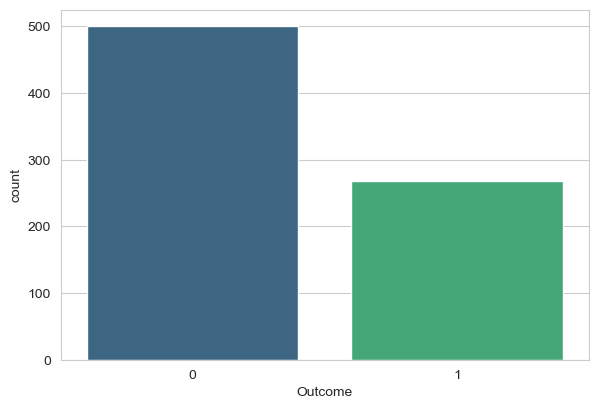

In [14]:
plt.figure(figsize=(15,10))
 #Outcome distribution
plt.subplot(2,2,1)
sns.countplot(data=df_work, x="Outcome", palette='viridis')

Text(0.5, 1.0, 'Glucose Distribution')

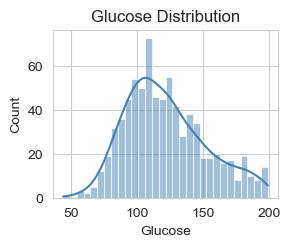

In [15]:
# 2. Glucose distribution
plt.subplot(2, 2, 2)
sns.histplot(df_work["Glucose"], bins=30, kde=True, color="steelblue")
plt.title("Glucose Distribution")


Text(0.5, 1.0, 'BMI vs Outcome')

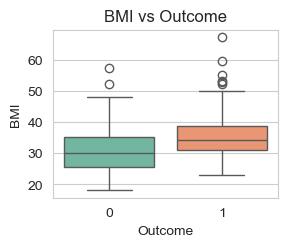

In [16]:

# 3. BMI vs Outcome
plt.subplot(2, 2, 3)
sns.boxplot(data=df_work, x="Outcome", y="BMI", palette="Set2")
plt.title("BMI vs Outcome")

Text(0.5, 1.0, 'Feature Correlation')

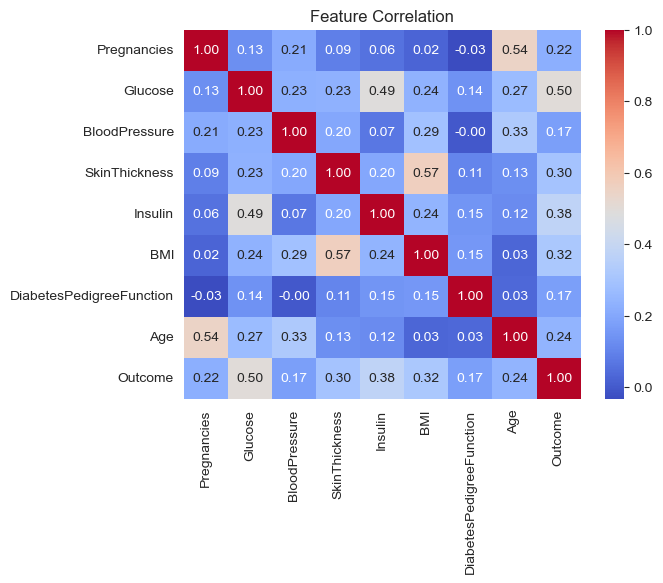

In [20]:
# 4. Correlation heatmap

sns.heatmap(df_work.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation")


In [23]:
X = df_work.drop("Outcome", axis=1)
y = df_work['Outcome']